In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

HARTREE_TO_KCAL_MOL = 627.5095
BOHR_TO_ANGSTROM = 0.529177

In [2]:
def c6(alpha_i, alpha_j, m1_i, m1_j):
    """XDM C6 coefficient calculation for heteroatomic case."""
    return (alpha_i * alpha_j * m1_i * m1_j) / (alpha_j * m1_i + alpha_i * m1_j + 1e-16)


def c8(alpha_i, m1_i, m2_i, alpha_j, m1_j, m2_j):
    """XDM C8 coefficient calculation for heteroatomic case."""
    num = alpha_i * alpha_j * (m1_i * m2_j + m2_i * m1_j)
    denom = alpha_j * m1_i + alpha_i * m1_j + 1e-16
    return (3 / 2.0) * (num / denom)


def c10(alpha_i, m1_i, m2_i, m3_i, alpha_j, m1_j, m2_j, m3_j):
    """XDM C10 coefficient calculation for homoatomic case."""
    num_term1 = 2 * (alpha_i * alpha_j) * (m1_i * m3_j + m3_i * m1_j)
    num_term2 = (21 / 5.0) * (alpha_i * alpha_j) * (m2_i * m2_j)
    denom_term1 = alpha_j * m1_i + alpha_i * m1_j + 1e-16
    denom_term2 = alpha_j * m1_i + alpha_i * m1_j + 1e-16
    return (num_term1 / denom_term1) + (num_term2 / denom_term2)

In [3]:
f_global = h5py.File("neb_im0.molden.input.h5", "r")
symbols_bytes = f_global["molecule"]["atomic_symbols"][:]
symbols = [s.decode("utf-8") for s in symbols_bytes]

In [4]:
# Polarizabilties of free atoms in atomic units (a.u.)
# Values taken from J. Chem. Theory Comput. 2024, 20, 17, 7469–7478
# https://doi.org/10.1021/acs.jctc.4c00784
ALPHA_FREE = {
    "H": 4.5,
    "C": 11.30,
    "F": 3.740,
    "Cl": 14.60,
}
alpha_free = np.array([ALPHA_FREE[symbol] for symbol in symbols])

In [5]:
MOMENTS_IDX = 3
r3_moments_dict = {}
for element in set(symbols):
    f = h5py.File(
        f"/home/joaomorado/repos/EMLE_PLUS_SI/sn2_reaction/elements/{element.lower()}/orca.molden.input.h5",
        "r",
    )
    r3_moments_dict[element] = f["mbis"]["horton"]["radial_moments"][:, MOMENTS_IDX][0]
r3_moments_free = np.array([r3_moments_dict[symbol] for symbol in symbols])

In [6]:
f["molecule"]["coordinates"][:]

array([[51.79172415,  2.40562137, 52.64021308]])

In [7]:
m1_list = []
m2_list = []
m3_list = []
vol_ratio_list = []
alpha_list = []
rc = []

for i in range(26):
    f = h5py.File(f"neb_im{i}.molden.input.h5", "r")
    m1 = f["mbis"]["xdm"]["mbis"]["xdm_results"]["<M1^2>"][:]
    m2 = f["mbis"]["xdm"]["mbis"]["xdm_results"]["<M2^2>"][:]
    m3 = f["mbis"]["xdm"]["mbis"]["xdm_results"]["<M3^2>"][:]
    r3_moments = f["mbis"]["horton"]["radial_moments"][:, MOMENTS_IDX]
    vol_ratio = r3_moments / r3_moments_free
    alpha = alpha_free * vol_ratio
    alpha_list.append(alpha)
    m1_list.append(m1)
    m2_list.append(m2)
    m3_list.append(m3)
    vol_ratio_list.append(vol_ratio)

    # Calculate the reaction coordinate
    # The reaction coordinate is defined as the difference in the C-Cl and C-F bond lengths
    coordinates = f["molecule"]["coordinates"][:]
    c_index = symbols.index("C")
    f_index = symbols.index("F")
    cl_index = symbols.index("Cl")
    c_f_distance = (
        np.linalg.norm(coordinates[c_index] - coordinates[f_index]) * BOHR_TO_ANGSTROM
    )
    c_cl_distance = (
        np.linalg.norm(coordinates[c_index] - coordinates[cl_index]) * BOHR_TO_ANGSTROM
    )
    rc.append(c_cl_distance - c_f_distance)


m1 = np.array(m1_list)
m2 = np.array(m2_list)
m3 = np.array(m3_list)
vol_ratio = np.array(vol_ratio_list)
alpha = np.array(alpha_list)
rc = np.array(rc)

In [8]:
c6_coeffs = c6(alpha, alpha, m1, m1)
c8_coeffs = c8(alpha, m1, m2, alpha, m1, m2)
c10_coeffs = c10(alpha, m1, m2, m3, alpha, m1, m2, m3)

In [9]:
# Read arc length and energy from NEB output
arclength = []
energy = []

# Read from neb.final.interp file
try:
    with open("../neb.final.interp", "r") as f:
        lines = f.readlines()
        for line in lines:
            line = line.strip()
            if not line or line.upper() in ["INTERP.:", "IMAGES:", "E", "ITERATION:"]:
                continue
            parts = line.split()
            if len(parts) >= 3:
                try:
                    arclength.append(float(parts[1]))
                    energy.append(float(parts[2]))
                except ValueError:
                    continue

    # Get only the arc lengths and energies for images (first 26 values)
    arclength = np.array(arclength[:26])
    energy = np.array(energy[:26])
    print(f"Arc length values loaded: {len(arclength)} points")
    print(f"Arc length range: {arclength[0]:.3f} to {arclength[-1]:.3f} Bohr")
    print(f"Energy range: {energy.min():.6f} to {energy.max():.6f} Ha")
except FileNotFoundError:
    print("Could not find neb.final.interp file")
    arclength = np.arange(26)
    energy = np.zeros(26)

Arc length values loaded: 26 points
Arc length range: 0.000 to 2.387 Bohr
Energy range: -0.041485 to 0.004188 Ha


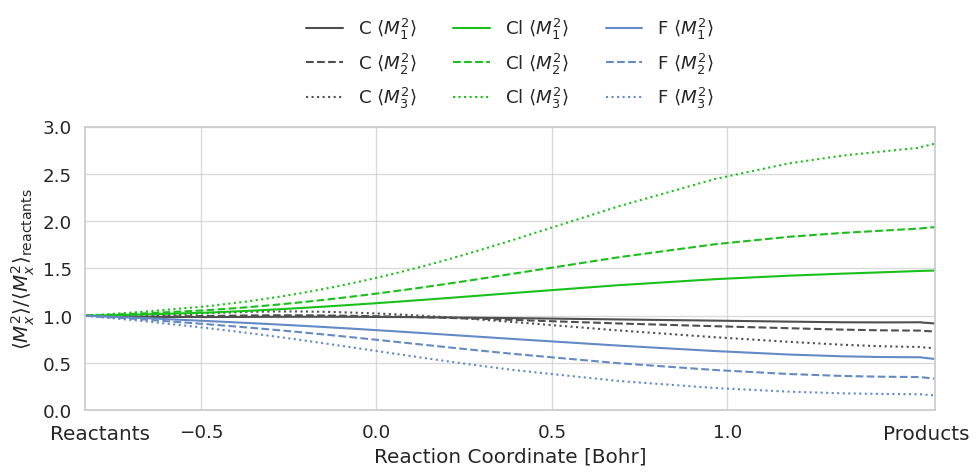

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 5))

# Define colors for elements
color_map = {"H": "grey", "C": "#4f4f4f", "Cl": "#1ac01a", "F": "#638ac5"}

# Shift energy so maximum is at 0
energy_offset = energy.argmax()
energy_shifted = energy - energy_offset

arclength_offset = arclength[energy.argmax()]
arclength = arclength - arclength_offset

# use rc
arclength = rc

for i in range(6):
    if symbols[i] in ["H"]:
        continue

    color = color_map.get(symbols[i], "black")

    ax.plot(
        arclength,
        m1[:, i] / m1[0, i],
        label=rf"{symbols[i]} $\langle M^2_1 \rangle$",
        color=color,
        linestyle="-",
    )

    ax.plot(
        arclength,
        m2[:, i] / m2[0, i],
        label=rf"{symbols[i]} $\langle M^2_2 \rangle$",
        color=color,
        linestyle="--",
    )

    ax.plot(
        arclength,
        m3[:, i] / m3[0, i],
        label=rf"{symbols[i]} $\langle M^2_3 \rangle$",
        color=color,
        linestyle=":",
    )

ax.set_xlabel("Reaction Coordinate [Bohr]")
ax.set_ylabel(r"$\langle M^2_x \rangle / \langle M^2_x \rangle_{\mathrm{reactants}}$")
ax.grid(True, alpha=0.7)
ax.set_xlim(arclength.min(), arclength.max())
ax.set_ylim(0, 3)
ax.set_xticks([-0.5, 0, 0.5, 1.0])


ax.text(
    arclength.min() - 0.1,
    ax.get_ylim()[0]
    - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]),  # slightly below y-axis minimum
    "Reactants",
    ha="left",
    va="top",
)

ax.text(
    arclength.max() + 0.1,
    ax.get_ylim()[0] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
    "Products",
    ha="right",
    va="top",
)

# Legend above the plot with 5 columns
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.00), ncol=3, frameon=False)

plt.tight_layout()
plt.savefig("mbis_moments.png", dpi=300)
plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\A'
<>:49: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_507736/2665027157.py:49: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel("Reaction Coordinate [$\AA$]")


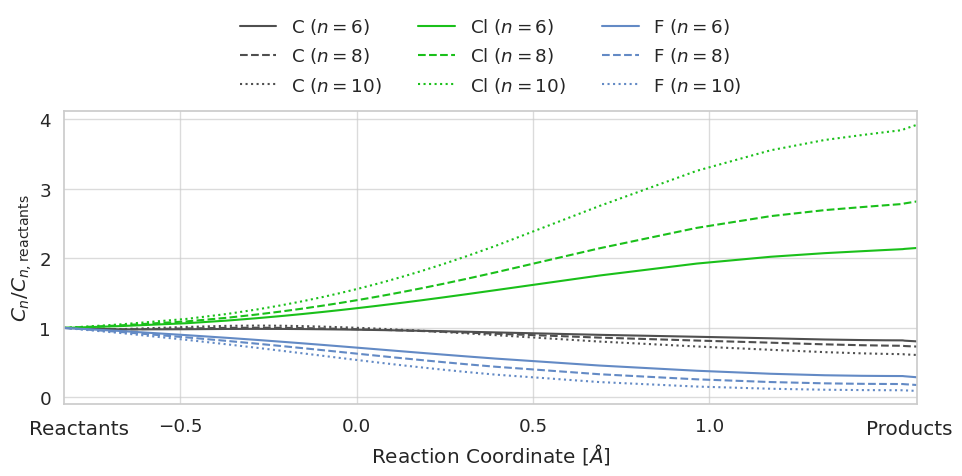

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 5))

color_map = {"H": "grey", "C": "#4f4f4f", "Cl": "#1ac01a", "F": "#638ac5"}

# Shift energy so maximum is at 0
energy_offset = energy.argmax()
energy_shifted = energy - energy_offset

arclength_offset = arclength[energy.argmax()]
arclength = arclength - arclength_offset

arclength = rc

for i in range(6):
    if symbols[i] in ["H"]:
        continue

    color = color_map.get(symbols[i], "black")

    ax.plot(
        arclength,
        c6_coeffs[:, i] / c6_coeffs[0, i],
        label=rf"{symbols[i]} $(n=6)$",
        color=color,
        linestyle="-",
    )

    ax.plot(
        arclength,
        c8_coeffs[:, i] / c8_coeffs[0, i],
        label=rf"{symbols[i]} $(n=8)$",
        color=color,
        linestyle="--",
    )

    ax.plot(
        arclength,
        c10_coeffs[:, i] / c10_coeffs[0, i],
        label=rf"{symbols[i]} $(n=10)$",
        color=color,
        linestyle=":",
    )

ax.set_xlabel("Reaction Coordinate [$\AA$]")
ax.set_ylabel(r"$C_n / C_{n,\mathrm{reactants}}$")
ax.grid(True, alpha=0.7)
ax.set_xlim(arclength.min(), arclength.max())
ax.set_xticks([-0.5, 0, 0.5, 1.0])

ax.text(
    arclength.min() - 0.1,  # x position
    ax.get_ylim()[0]
    - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]),  # slightly below y-axis minimum
    "Reactants",
    ha="left",
    va="top",
)

ax.text(
    arclength.max() + 0.1,
    ax.get_ylim()[0] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
    "Products",
    ha="right",
    va="top",
)

# Legend above the plot with 5 columns
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.00), ncol=3, frameon=False)

plt.tight_layout()
plt.savefig("mbis_disp_coefficients.pdf", dpi=300, bbox_inches="tight")
plt.show()